# Exploratory Data Analysis (EDA)

## Objetivo

Analizar la calidad de los datos, comprender el comportamiento de usuarios y productos, identificar patrones de consumo y detectar posibles riesgos para el modelado del sistema de recomendación.

## Preguntas de negocio

- ¿Existen problemas de calidad de datos?
- ¿Cómo se distribuyen las compras de los usuarios?
- ¿Cómo se distribuyen las compras de los productos?
- ¿Existe comportamiento Long Tail?
- ¿Existe sparsity significativa en la matriz usuario-producto?
- ¿Cuáles son los productos más populares?
- ¿Cómo se comportan los usuarios a lo largo del tiempo?

In [1]:
# Importar librerías para análisis exploratorio

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

In [2]:
# Cargar datasets principales

aisles = pd.read_csv("../data/raw/instacart/aisles.csv")
departments = pd.read_csv("../data/raw/instacart/departments.csv")
orders = pd.read_csv("../data/raw/instacart/orders.csv")
products = pd.read_csv("../data/raw/instacart/products.csv")
prior = pd.read_csv("../data/raw/instacart/order_products__prior.csv")
train = pd.read_csv("../data/raw/instacart/order_products__train.csv")

In [3]:
# Agrupar datasets para análisis de calidad

datasets = {
    "aisles": aisles,
    "departments": departments,
    "orders": orders,
    "products": products,
    "prior": prior,
    "train": train
}

In [4]:
# Analizar valores faltantes por tabla

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(df.isnull().sum())


AISLES
aisle_id    0
aisle       0
dtype: int64

DEPARTMENTS
department_id    0
department       0
dtype: int64

ORDERS
order_id                       0
user_id                        0
eval_set                       0
order_number                   0
order_dow                      0
order_hour_of_day              0
days_since_prior_order    206209
dtype: int64

PRODUCTS
product_id       0
product_name     0
aisle_id         0
department_id    0
dtype: int64

PRIOR
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64

TRAIN
order_id             0
product_id           0
add_to_cart_order    0
reordered            0
dtype: int64


In [5]:
# Analizar registros duplicados

for name, df in datasets.items():
    print(f"\n{name.upper()}")
    print(f"Duplicados: {df.duplicated().sum()}")


AISLES
Duplicados: 0

DEPARTMENTS
Duplicados: 0

ORDERS
Duplicados: 0

PRODUCTS
Duplicados: 0

PRIOR
Duplicados: 0

TRAIN
Duplicados: 0


# Calidad de datos

## Valores faltantes

Se identificaron valores nulos únicamente en la columna `days_since_prior_order` de la tabla `orders`.

Estos valores corresponden al primer pedido realizado por cada usuario, por lo que representan una ausencia lógica de información y no un problema de calidad de datos.

## Duplicados

No se identificaron registros duplicados en ninguna de las tablas analizadas.

Por lo tanto, no será necesario realizar procesos de eliminación de duplicados durante la etapa de preparación de datos.

In [6]:
# Cantidad de pedidos por usuario

orders_per_user = (
    orders.groupby("user_id")
    .size()
    .reset_index(name="order_count")
)

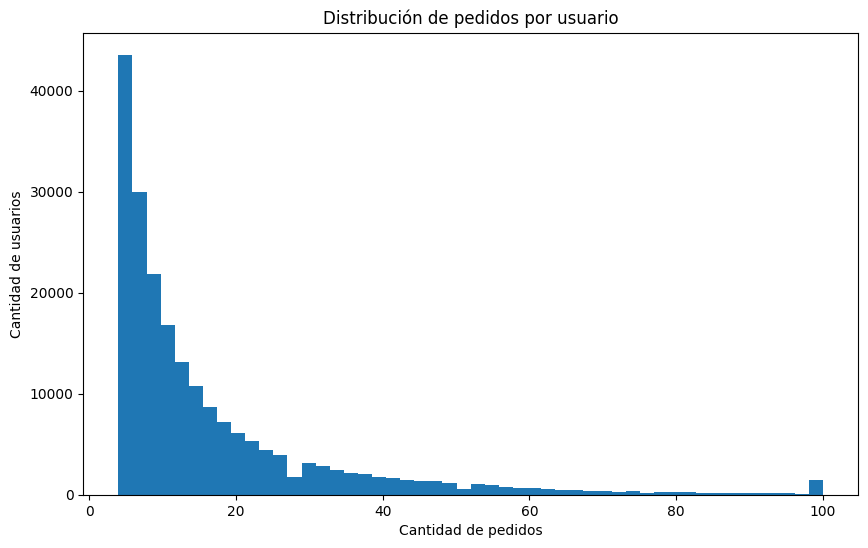

In [7]:
# Distribución de pedidos por usuario

plt.figure(figsize=(10,6))

plt.hist(
    orders_per_user["order_count"],
    bins=50
)

plt.title("Distribución de pedidos por usuario")
plt.xlabel("Cantidad de pedidos")
plt.ylabel("Cantidad de usuarios")

plt.show()

In [8]:
# Estadísticas descriptivas

orders_per_user["order_count"].describe()

count    206209.000000
mean         16.590367
std          16.654774
min           4.000000
25%           6.000000
50%          10.000000
75%          20.000000
max         100.000000
Name: order_count, dtype: float64

# Comportamiento de los usuarios

La distribución de pedidos por usuario presenta una fuerte asimetría positiva.

La mayoría de los usuarios registra una cantidad relativamente baja de pedidos, mientras que un grupo reducido concentra una gran actividad de compra.

## Hallazgos

- Promedio de pedidos por usuario: 16,59
- Mediana de pedidos por usuario: 10
- Máximo observado: 100 pedidos

Estos resultados indican que existe suficiente historial de interacción para construir perfiles de consumo personalizados.

Sin embargo, también se observa la presencia de usuarios con pocas compras, lo que introduce potenciales escenarios de Cold Start que deberán ser considerados durante el modelado.

In [9]:
# Cantidad de compras por producto

product_sales = (
    prior.groupby("product_id")
    .size()
    .reset_index(name="purchase_count")
)

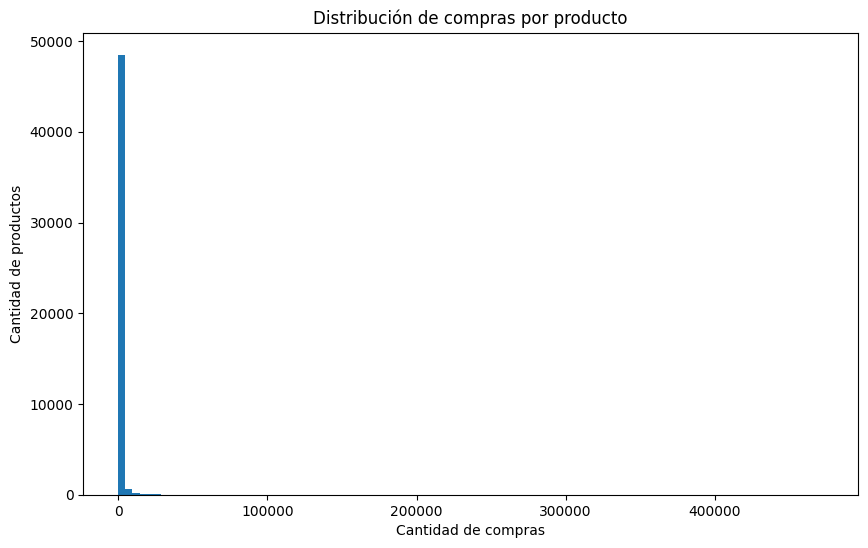

In [10]:
# Distribución de compras por producto

plt.figure(figsize=(10,6))

plt.hist(
    product_sales["purchase_count"],
    bins=100
)

plt.title("Distribución de compras por producto")
plt.xlabel("Cantidad de compras")
plt.ylabel("Cantidad de productos")

plt.show()

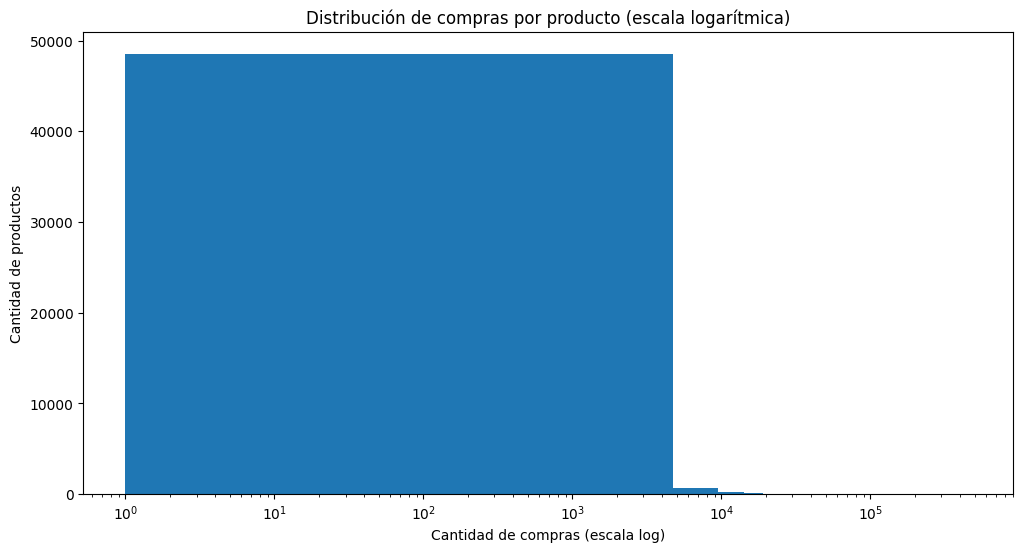

In [11]:
# Distribución de compras por producto (escala logarítmica)

plt.figure(figsize=(12,6))

plt.hist(
    product_sales["purchase_count"],
    bins=100
)

plt.xscale("log")

plt.title("Distribución de compras por producto (escala logarítmica)")
plt.xlabel("Cantidad de compras (escala log)")
plt.ylabel("Cantidad de productos")

plt.show()

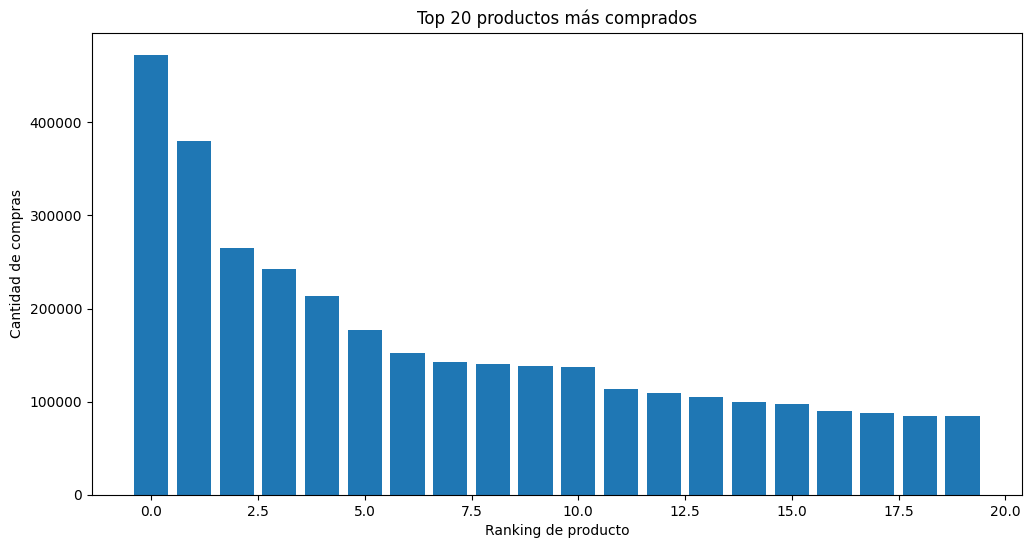

In [12]:
# Top 20 productos más comprados

top_products = (
    product_sales
    .sort_values("purchase_count", ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

plt.bar(
    range(len(top_products)),
    top_products["purchase_count"]
)

plt.title("Top 20 productos más comprados")
plt.xlabel("Ranking de producto")
plt.ylabel("Cantidad de compras")

plt.show()

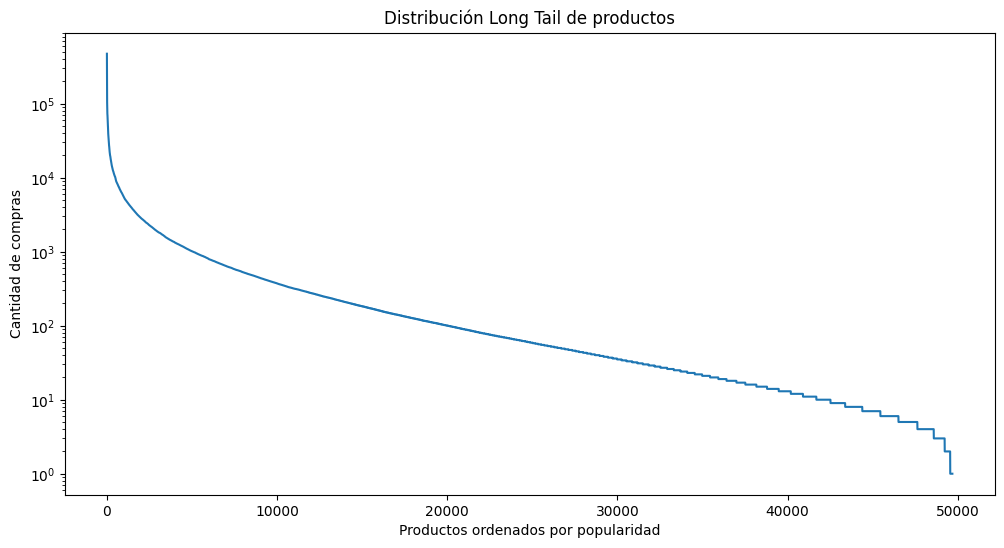

In [13]:
# Curva Long Tail

sales_sorted = (
    product_sales["purchase_count"]
    .sort_values(ascending=False)
    .reset_index(drop=True)
)

plt.figure(figsize=(12,6))

plt.plot(sales_sorted)

plt.title("Distribución Long Tail de productos")
plt.xlabel("Productos ordenados por popularidad")
plt.ylabel("Cantidad de compras")

plt.yscale("log")

plt.show()

In [14]:
# Top 10 productos más comprados

product_sales.sort_values(
    by="purchase_count",
    ascending=False
).head(10)

,product_id,purchase_count
24848,24852,472565
13172,13176,379450
21133,21137,264683
21899,21903,241921
47198,47209,213584
47755,47766,176815
47615,47626,152657
16793,16797,142951
26204,26209,140627
27839,27845,137905


# Distribución de compras por producto

Se observa una distribución claramente asimétrica de las compras por producto.

Un grupo reducido de productos concentra una gran cantidad de compras, mientras que la mayoría del catálogo presenta una frecuencia de compra significativamente menor.

## Hallazgos

- El producto más comprado registra 472.565 compras.
- La mediana de compras por producto es de 60.
- El promedio de compras por producto es de 652.

La diferencia entre media y mediana evidencia una fuerte concentración de compras en pocos productos.

## Implicancias para el sistema de recomendación

Este comportamiento corresponde al fenómeno conocido como Long Tail, característico de plataformas de e-commerce.

Por este motivo, un sistema basado únicamente en popularidad tendería a recomendar siempre los mismos productos, limitando la personalización.

Se evaluarán modelos capaces de capturar preferencias individuales de los usuarios para recomendar productos menos populares pero potencialmente relevantes.

In [15]:
# Cantidad de pedidos por día de la semana

orders["order_dow"].value_counts().sort_index()

order_dow
0    600905
1    587478
2    467260
3    436972
4    426339
5    453368
6    448761
Name: count, dtype: int64

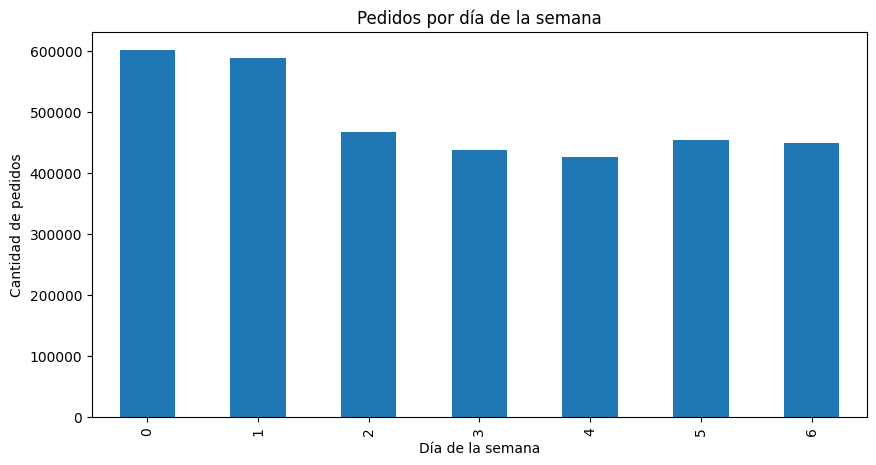

In [16]:
# Distribución de pedidos por día de la semana

orders["order_dow"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Pedidos por día de la semana")
plt.xlabel("Día de la semana")
plt.ylabel("Cantidad de pedidos")

plt.show()

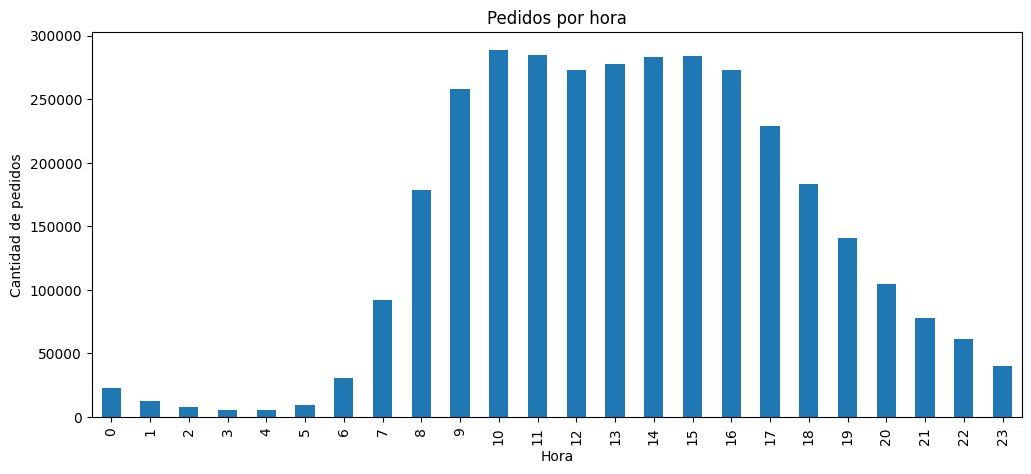

In [17]:
# Distribución de pedidos por hora del día

orders["order_hour_of_day"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(12,5)
)

plt.title("Pedidos por hora")
plt.xlabel("Hora")
plt.ylabel("Cantidad de pedidos")

plt.show()

# Comportamiento temporal de compra

Se analizó la distribución de pedidos por día de la semana y por hora del día.

La variable `order_dow` representa el día de la semana en que se realizó el pedido. Sin embargo, antes de interpretar cada categoría será necesario confirmar la codificación utilizada por el dataset.

Por otro lado, la variable `order_hour_of_day` permite identificar patrones horarios de compra.

# Tamaño de las canastas de compra

Se analizó la cantidad de productos incluidos en cada pedido para comprender el comportamiento de compra de los usuarios y evaluar el potencial de técnicas de recomendación basadas en asociaciones entre productos.

In [18]:
basket_size = prior.groupby(
    "order_id"
).size()

basket_size.describe()

count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
dtype: float64

<Axes: >

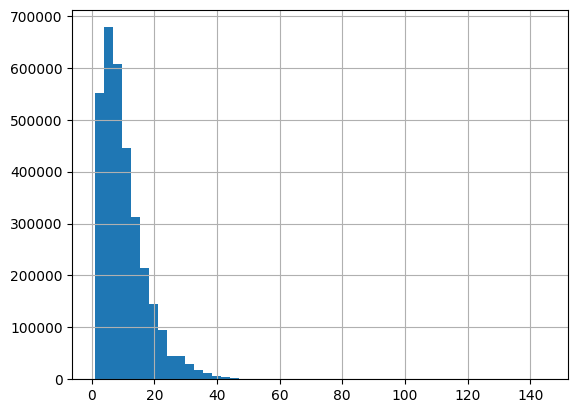

In [19]:
basket_size.hist(bins=50)

## Hallazgos

Se analizaron 3.214.874 pedidos históricos.

- El tamaño promedio de una canasta es de 10 productos.
- La mediana es de 8 productos por pedido.
- El 75% de los pedidos contiene hasta 14 productos.
- Existen pedidos con hasta 145 productos, aunque representan casos excepcionales.

La distribución presenta una asimetría positiva, con una gran concentración de pedidos pequeños y medianos, acompañada por una cola de pedidos de gran tamaño.

## Implicancias para el modelado

- Los pedidos contienen múltiples productos por transacción.
- Esto permite analizar relaciones entre productos comprados en conjunto.
- Existe potencial para aplicar técnicas de Market Basket Analysis y estrategias de Cross Selling.
- La presencia de múltiples productos por pedido permite construir recomendaciones complementarias además de recomendaciones personalizadas.

# Potencial para Market Basket Analysis

Dado que cada pedido contiene múltiples productos, resulta posible analizar asociaciones de compra entre artículos y generar recomendaciones complementarias.

In [20]:
# Analizar comportamiento de recompra

prior["reordered"].value_counts()

reordered
1    19126536
0    13307953
Name: count, dtype: int64

In [21]:
# Analizar porcentaje de recompra

prior["reordered"].value_counts(normalize=True) * 100

reordered
1    58.969747
0    41.030253
Name: proportion, dtype: float64

# Comportamiento de recompra

La variable `reordered` indica si un producto ya había sido comprado previamente por el usuario.

## Resultados

- 58,97% de las compras corresponden a productos previamente adquiridos.
- 41,03% corresponden a primeras compras.

## Hallazgo

Los usuarios presentan una fuerte tendencia a repetir compras de productos ya conocidos.

Este comportamiento resulta especialmente favorable para sistemas de recomendación basados en historial de consumo, ya que evidencia la existencia de patrones de preferencia estables a lo largo del tiempo.

## Implicancias para el modelado

La elevada tasa de recompra sugiere que técnicas de Collaborative Filtering y modelos basados en interacciones históricas podrían capturar adecuadamente las preferencias de los usuarios.

## Oportunidades de negocio

La alta tasa de recompra observada sugiere la existencia de hábitos de consumo recurrentes.

Esta característica no solo favorece la construcción de modelos de recomendación personalizados, sino que también podría utilizarse para identificar oportunidades de recompra automática, promociones dirigidas y estrategias de fidelización de clientes.

# Implicancias para el sistema de recomendación

A partir del análisis exploratorio realizado se identificaron características relevantes del dataset que impactarán directamente en las decisiones de modelado.

Las siguientes observaciones permiten justificar la elección de los algoritmos a evaluar y anticipar posibles limitaciones del sistema.

## Sparsity de la matriz usuario-producto

La matriz usuario-producto presenta una dispersión aproximada del 99,68%.

### Implicancias

- La mayoría de los usuarios interactúa únicamente con una pequeña porción del catálogo.
- Los enfoques basados únicamente en reglas simples o popularidad pueden resultar insuficientes.
- Será necesario evaluar modelos capaces de aprender patrones a partir de interacciones parciales entre usuarios y productos.

## Long Tail de productos

La distribución de compras presenta un comportamiento Long Tail.

Un grupo reducido de productos concentra gran parte de las compras, mientras que la mayoría del catálogo registra una baja frecuencia de consumo.

### Implicancias

- Un recomendador basado únicamente en popularidad tenderá a recomendar siempre los mismos productos.
- Resulta importante evaluar modelos que permitan descubrir productos relevantes más allá de los más vendidos.
- Se utilizará un modelo baseline basado en popularidad para comparar su desempeño contra modelos personalizados.

## Comportamiento de recompra

El 58,97% de las compras corresponde a productos adquiridos previamente por los usuarios.

### Implicancias

- Existen patrones de consumo estables.
- Los usuarios muestran preferencias recurrentes.
- Los modelos basados en historial de consumo tienen potencial para capturar dichas preferencias.

## Cold Start

Se observan usuarios con poca actividad dentro del sistema.

### Implicancias

- Algunos usuarios contarán con información limitada para generar recomendaciones personalizadas.
- Este escenario representa un desafío conocido como Cold Start.
- Los modelos deberán contemplar mecanismos alternativos para usuarios con escaso historial.

## Estrategia preliminar de modelado

A partir de los hallazgos obtenidos durante el EDA se decidió evaluar inicialmente dos enfoques:

1. Modelo Baseline basado en popularidad de productos.
2. Modelo de Collaborative Filtering basado en interacciones usuario-producto.

La comparación entre ambos permitirá determinar si la personalización aporta mejoras respecto de una estrategia simple basada en productos populares.

Adicionalmente, se explorará la posibilidad de incorporar técnicas de Market Basket Analysis para identificar productos frecuentemente comprados en conjunto y generar recomendaciones orientadas a Cross Selling.

Este enfoque permitiría complementar las recomendaciones personalizadas con sugerencias de productos asociados a patrones reales de compra.

# Análisis orientado a reducción de ruido para el sistema de recomendación

## Objetivo

En esta sección se analiza la distribución de interacciones a nivel producto y pasillo (*aisle*) con el objetivo de identificar posibles fuentes de ruido para el sistema de recomendación.

En particular, se busca evaluar:

- Presencia de productos con muy baja frecuencia de compra.
- Existencia de comportamiento Long Tail.
- Diferencias de escala entre pasillos.
- Riesgo de aplicar filtros globales que eliminen productos válidos dentro de categorías naturalmente pequeñas.
- Posibles criterios de reducción de ruido para mejorar la calidad del modelado.

Este análisis permite conectar el EDA con decisiones posteriores de preprocesamiento, feature engineering y entrenamiento de modelos.

In [22]:
# Crear dataset unificado de compras + productos + pasillos + departamentos

prior_full = (
    prior
    .merge(products, on="product_id", how="left")
    .merge(aisles, on="aisle_id", how="left")
    .merge(departments, on="department_id", how="left")
)

prior_full.head()

,order_id,product_id,add_to_cart_order,reordered,product_name,aisle_id,department_id,aisle,department
0,2,33120,1,1,Organic Egg Whites,86,16,eggs,dairy eggs
1,2,28985,2,1,Michigan Organic Kale,83,4,fresh vegetables,produce
2,2,9327,3,0,Garlic Powder,104,13,spices seasonings,pantry
3,2,45918,4,1,Coconut Butter,19,13,oils vinegars,pantry
4,2,30035,5,0,Natural Sweetener,17,13,baking ingredients,pantry


In [23]:
# Compras por producto

product_purchase_counts = (
    prior_full
    .groupby(["product_id", "product_name", "aisle", "department"])
    .size()
    .reset_index(name="purchase_count")
    .sort_values("purchase_count", ascending=False)
)

product_purchase_counts.head(20)

,product_id,product_name,aisle,department,purchase_count
24848,24852,Banana,fresh fruits,produce,472565
13172,13176,Bag of Organic Bananas,fresh fruits,produce,379450
21133,21137,Organic Strawberries,fresh fruits,produce,264683
21899,21903,Organic Baby Spinach,packaged vegetables fruits,produce,241921
47198,47209,Organic Hass Avocado,fresh fruits,produce,213584
47755,47766,Organic Avocado,fresh fruits,produce,176815
47615,47626,Large Lemon,fresh fruits,produce,152657
16793,16797,Strawberries,fresh fruits,produce,142951
26204,26209,Limes,fresh fruits,produce,140627
27839,27845,Organic Whole Milk,milk,dairy eggs,137905


In [24]:
# Estadísticas generales

product_purchase_counts["purchase_count"].describe()

count     49677.000000
mean        652.907563
std        4792.114416
min           1.000000
25%          17.000000
50%          60.000000
75%         260.000000
max      472565.000000
Name: purchase_count, dtype: float64

In [25]:
# Productos con baja frecuencia

thresholds = [1, 5, 10, 20, 50, 100]
total_products = product_purchase_counts["product_id"].nunique()

low_frequency_summary = []

for threshold in thresholds:
    qty = (product_purchase_counts["purchase_count"] <= threshold).sum()
    pct = qty / total_products * 100
    
    low_frequency_summary.append({
        "umbral_compras": f"<= {threshold}",
        "cantidad_productos": qty,
        "porcentaje_catalogo": round(pct, 2)
    })

low_frequency_summary = pd.DataFrame(low_frequency_summary)
low_frequency_summary

,umbral_compras,cantidad_productos,porcentaje_catalogo
0,<= 1,131,0.26
1,<= 5,3171,6.38
2,<= 10,7995,16.09
3,<= 20,14242,28.67
4,<= 50,23205,46.71
5,<= 100,29698,59.78


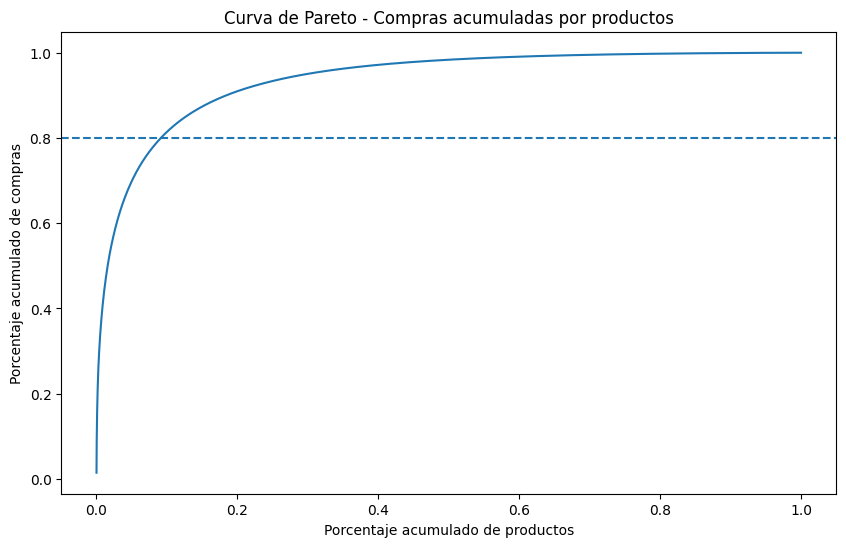

In [26]:
# Curva de Pareto

pareto_products = product_purchase_counts.copy()

pareto_products["purchase_pct"] = (
    pareto_products["purchase_count"] / pareto_products["purchase_count"].sum()
)

pareto_products["purchase_pct_acum"] = pareto_products["purchase_pct"].cumsum()

pareto_products["product_pct_acum"] = (
    np.arange(1, len(pareto_products) + 1) / len(pareto_products)
)

plt.figure(figsize=(10, 6))
plt.plot(
    pareto_products["product_pct_acum"],
    pareto_products["purchase_pct_acum"]
)
plt.axhline(0.8, linestyle="--")
plt.title("Curva de Pareto - Compras acumuladas por productos")
plt.xlabel("Porcentaje acumulado de productos")
plt.ylabel("Porcentaje acumulado de compras")
plt.show()

In [27]:
# Porcentaje de productos que explica el 80% de las compras

products_80 = pareto_products[pareto_products["purchase_pct_acum"] <= 0.8]

pct_products_80 = len(products_80) / len(pareto_products) * 100

print(f"El {pct_products_80:.2f}% de los productos concentra aproximadamente el 80% de las compras.")

El 9.13% de los productos concentra aproximadamente el 80% de las compras.


## Interpretación

La distribución de compras por producto permite observar si existe concentración de demanda en pocos productos y una gran cantidad de productos con baja frecuencia de compra.

Este comportamiento es relevante para el sistema de recomendación porque los productos con muy pocas interacciones pueden aportar poca señal al modelo y aumentar la dispersión de la matriz usuario-producto.

Sin embargo, no necesariamente deben eliminarse con un umbral global, ya que algunos productos pueden ser poco frecuentes a nivel general pero representativos dentro de su propio pasillo.

# Análisis de Long Tail por pasillo

## Objetivo

Analizar si todos los pasillos presentan la misma escala de compras.

Este análisis permite evaluar si los criterios de filtrado deberían aplicarse de forma global o relativa a cada categoría.

In [28]:
# Estadísticas por pasillo

aisle_product_stats = (
    product_purchase_counts
    .groupby("aisle")
    .agg(
        product_count=("product_id", "nunique"),
        total_purchases=("purchase_count", "sum"),
        avg_purchases_per_product=("purchase_count", "mean"),
        median_purchases_per_product=("purchase_count", "median"),
        std_purchases_per_product=("purchase_count", "std"),
        min_purchases=("purchase_count", "min"),
        max_purchases=("purchase_count", "max")
    )
    .reset_index()
    .sort_values("total_purchases", ascending=False)
)

aisle_product_stats.head(20)

,aisle,product_count,total_purchases,avg_purchases_per_product,median_purchases_per_product,std_purchases_per_product,min_purchases,max_purchases
50,fresh fruits,382,3642188,9534.523560,386.0,40105.378548,3,472565
53,fresh vegetables,569,3418021,6007.066784,450.0,14914.051498,2,113426
98,packaged vegetables fruits,615,1765313,2870.427642,219.0,14086.689883,3,241921
133,yogurt,1026,1452343,1415.538986,225.0,3256.578457,1,29893
93,packaged cheese,890,979763,1100.857303,145.5,3970.438082,2,59676
83,milk,243,891015,3666.728395,515.0,10960.531729,2,137905
131,water seltzer sparkling water,344,841533,2446.316860,243.0,7364.550388,1,75886
25,chips pretzels,989,722470,730.505561,116.0,1894.005809,1,24950
119,soy lactosefree,293,638253,2178.337884,306.0,6050.034586,1,57895
11,bread,557,584834,1049.971275,177.0,3331.831323,3,60816


In [29]:
# Percentiles de compras por producto dentro de cada pasillo

aisle_percentiles = (
    product_purchase_counts
    .groupby("aisle")["purchase_count"]
    .quantile([0.10, 0.25, 0.50, 0.75, 0.90])
    .unstack()
    .reset_index()
)

aisle_percentiles.columns = [
    "aisle",
    "p10",
    "p25",
    "p50_mediana",
    "p75",
    "p90"
]

aisle_percentiles = aisle_percentiles.merge(
    aisle_product_stats[["aisle", "product_count", "total_purchases"]],
    on="aisle",
    how="left"
)

aisle_percentiles = aisle_percentiles.sort_values("total_purchases", ascending=False)

aisle_percentiles.head(20)

,aisle,p10,p25,p50_mediana,p75,p90,product_count,total_purchases
50,fresh fruits,15.0,52.50,386.0,3282.00,12441.3,382,3642188
53,fresh vegetables,16.0,65.00,450.0,3515.00,17405.4,569,3418021
98,packaged vegetables fruits,17.4,46.00,219.0,1037.00,3956.6,615,1765313
133,yogurt,16.0,52.00,225.0,1110.25,3967.5,1026,1452343
93,packaged cheese,14.0,39.00,145.5,609.25,1982.0,890,979763
83,milk,13.0,95.50,515.0,2679.50,9125.6,243,891015
131,water seltzer sparkling water,15.0,49.75,243.0,1353.25,5368.2,344,841533
25,chips pretzels,12.0,29.00,116.0,548.00,1799.4,989,722470
119,soy lactosefree,23.0,70.00,306.0,1655.00,5259.2,293,638253
11,bread,16.0,49.00,177.0,759.00,2659.4,557,584834


In [30]:
# Comparación media vs mediana por pasillo

aisle_mean_median = aisle_product_stats[
    ["aisle", "avg_purchases_per_product", "median_purchases_per_product", "total_purchases"]
].sort_values("total_purchases", ascending=False)

aisle_mean_median.head(20)

,aisle,avg_purchases_per_product,median_purchases_per_product,total_purchases
50,fresh fruits,9534.523560,386.0,3642188
53,fresh vegetables,6007.066784,450.0,3418021
98,packaged vegetables fruits,2870.427642,219.0,1765313
133,yogurt,1415.538986,225.0,1452343
93,packaged cheese,1100.857303,145.5,979763
83,milk,3666.728395,515.0,891015
131,water seltzer sparkling water,2446.316860,243.0,841533
25,chips pretzels,730.505561,116.0,722470
119,soy lactosefree,2178.337884,306.0,638253
11,bread,1049.971275,177.0,584834


## Interpretación

El análisis por pasillo muestra que las categorías no tienen la misma escala de compras ni la misma distribución interna.

Por este motivo, aplicar un único umbral global para eliminar productos poco frecuentes podría generar sesgos, eliminando productos válidos de pasillos naturalmente más pequeños.

Una alternativa más robusta sería evaluar filtros relativos por pasillo, por ejemplo utilizando percentiles o comparando cada producto contra la mediana de compras de su propia categoría.

## Variabilidad de las compras por pasillo

Además del promedio y la mediana, resulta útil analizar la variabilidad de las compras dentro de cada pasillo.

Para ello se calcula el **coeficiente de variación (CV)**, definido como la relación entre la desviación estándar y el promedio de compras por producto.

Esta métrica permite identificar categorías donde la popularidad de los productos es muy heterogénea, es decir, donde conviven unos pocos productos extremadamente populares con muchos productos de baja frecuencia.

Valores elevados del coeficiente de variación indican una mayor dispersión y una presencia más marcada del efecto **Long Tail** dentro del pasillo.

In [31]:
# Calcular el coeficiente de variación por pasillo

aisle_product_stats["coef_variacion"] = (
    aisle_product_stats["std_purchases_per_product"]
    / aisle_product_stats["avg_purchases_per_product"]
)

# Mostrar los pasillos con mayor variabilidad

aisle_product_stats.sort_values(
    "coef_variacion",
    ascending=False
).head(20)

,aisle,product_count,total_purchases,avg_purchases_per_product,median_purchases_per_product,std_purchases_per_product,min_purchases,max_purchases,coef_variacion
2,baby accessories,44,8160,185.454545,15.5,950.696940,1,6315,5.126307
85,missing,1255,69145,55.095618,12.0,277.535449,1,8366,5.037342
44,eye ear care,113,8974,79.415929,21.0,394.272833,2,4197,4.964657
98,packaged vegetables fruits,615,1765313,2870.427642,219.0,14086.689883,3,241921,4.907523
89,oils vinegars,375,245466,654.576000,64.0,2988.200771,1,50255,4.565094
132,white wines,147,30558,207.877551,28.0,894.802212,1,8246,4.304468
95,packaged poultry,99,118437,1196.333333,173.0,5145.596871,2,50281,4.301140
33,cream,161,318002,1975.167702,199.0,8480.810637,3,76360,4.293717
50,fresh fruits,382,3642188,9534.523560,386.0,40105.378548,3,472565,4.206333
49,fresh dips tapenades,327,355685,1087.721713,134.0,4524.610922,1,71314,4.159714


## Comparación entre promedio y mediana de compras por pasillo

La comparación entre el promedio y la mediana permite evaluar el grado de asimetría en la distribución de compras de cada pasillo.

Cuando el promedio es considerablemente mayor que la mediana, suele indicar la existencia de unos pocos productos con una cantidad muy elevada de compras que elevan la media del conjunto.

Este comportamiento es característico de distribuciones con efecto **Long Tail**, donde una pequeña proporción de productos concentra gran parte de las interacciones.

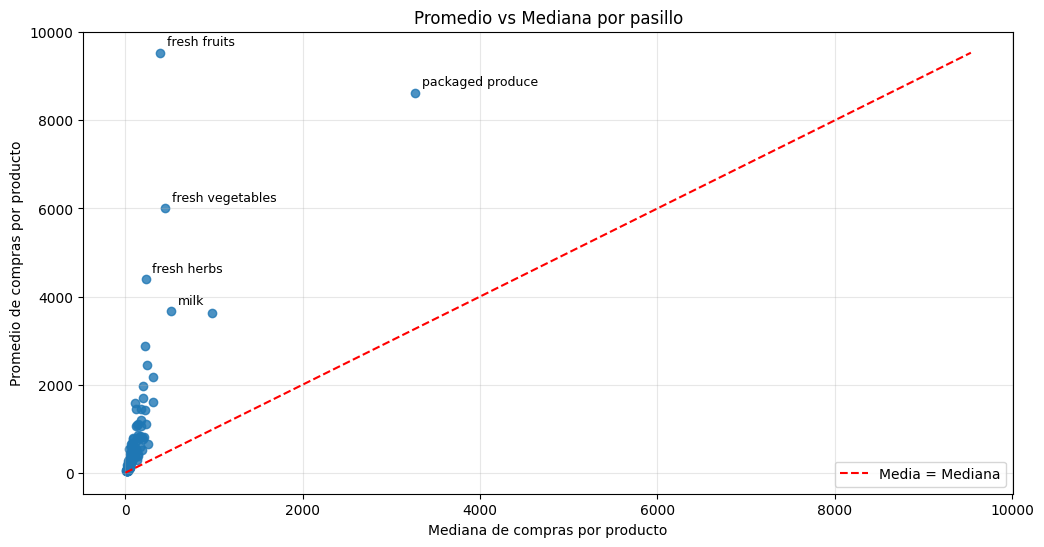

In [35]:
# Comparar promedio y mediana mediante un gráfico de dispersión

plt.figure(figsize=(12,6))

plt.scatter(
    aisle_product_stats["median_purchases_per_product"],
    aisle_product_stats["avg_purchases_per_product"],
    alpha=0.8
)

# Dibujar la diagonal donde Promedio = Mediana

lim = max(
    aisle_product_stats["median_purchases_per_product"].max(),
    aisle_product_stats["avg_purchases_per_product"].max()
)

plt.plot(
    [0, lim],
    [0, lim],
    "--",
    color="red",
    label="Media = Mediana"
)

# Identificar los 5 pasillos con mayor diferencia entre promedio y mediana

aisle_product_stats["gap_media_mediana"] = (
    aisle_product_stats["avg_purchases_per_product"]
    - aisle_product_stats["median_purchases_per_product"]
)

top_gap = aisle_product_stats.nlargest(5, "gap_media_mediana")

# Etiquetar esos pasillos en el gráfico

for _, row in top_gap.iterrows():
    plt.annotate(
    row["aisle"],
    (
        row["median_purchases_per_product"],
        row["avg_purchases_per_product"]
    ),
    xytext=(5,5),
    textcoords="offset points",
    fontsize=9
)

plt.xlabel("Mediana de compras por producto")
plt.ylabel("Promedio de compras por producto")
plt.title("Promedio vs Mediana por pasillo")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

> **Hallazgo:** La mayoría de los pasillos presentan una media superior a la mediana, lo que evidencia distribuciones asimétricas con pocos productos extremadamente populares. Este comportamiento refuerza la conveniencia de utilizar métricas robustas (mediana o percentiles) para definir criterios de filtrado, en lugar de umbrales basados únicamente en el promedio.

### Interpretación

La mayoría de los pasillos se ubica por encima de la diagonal donde el promedio coincide con la mediana.

Esto indica que la distribución de compras dentro de las categorías es asimétrica: unos pocos productos concentran una gran cantidad de compras mientras que la mayoría presenta una frecuencia considerablemente menor.

Este comportamiento confirma la presencia del efecto **Long Tail** a nivel de pasillo y sugiere que el promedio puede verse fuertemente influenciado por valores extremos. En consecuencia, métricas más robustas como la mediana o los percentiles resultan más adecuadas para definir criterios de filtrado y reducción de ruido en futuras etapas del modelado.

## Análisis de Afinidad entre Categorías

### Objetivo

Además de analizar la frecuencia individual de compra de los productos, resulta importante comprender cómo se relacionan las distintas categorías dentro de un mismo pedido.

La identificación de pasillos frecuentemente comprados en conjunto permite descubrir patrones de consumo, oportunidades de venta cruzada (*cross-selling*) y relaciones entre categorías que pueden ser aprovechadas por los sistemas de recomendación.

Este análisis busca responder preguntas como:

- ¿Qué pasillos suelen comprarse juntos?
- ¿Existen categorías complementarias?
- ¿Es posible recomendar productos similares o complementarios dentro del mismo contexto de compra?

## Co-ocurrencia entre pasillos

Para cada pedido se identifican todos los pasillos presentes y posteriormente se generan las combinaciones de categorías que aparecen conjuntamente.

De esta manera es posible construir una matriz de afinidad entre pasillos, donde cada celda representa la cantidad de pedidos en los que dos categorías fueron compradas simultáneamente.

In [36]:
from itertools import combinations
from collections import Counter

In [37]:
# Obtener los pasillos presentes en cada pedido

order_aisles = (
    prior_full
    .groupby("order_id")["aisle"]
    .apply(lambda x: sorted(set(x)))
)

In [38]:
# Generar pares de pasillos

pair_counter = Counter()

for aisles_list in order_aisles:
    pair_counter.update(combinations(aisles_list, 2))

In [39]:
pairs_df = pd.DataFrame(
    [
        (a1, a2, count)
        for (a1, a2), count in pair_counter.items()
    ],
    columns=["aisle_1", "aisle_2", "co_occurrence"]
)

pairs_df.sort_values(
    "co_occurrence",
    ascending=False
).head(20)

,aisle_1,aisle_2,co_occurrence
158,fresh fruits,fresh vegetables,1021564
165,fresh fruits,packaged vegetables fruits,868883
19,fresh vegetables,packaged vegetables fruits,753740
422,fresh fruits,yogurt,604624
161,fresh fruits,milk,528593
162,fresh fruits,packaged cheese,498231
35,fresh vegetables,yogurt,463077
174,fresh vegetables,packaged cheese,433598
38,packaged vegetables fruits,yogurt,410646
173,fresh vegetables,milk,402145


## Matriz de afinidad entre pasillos

La matriz de co-ocurrencia permite visualizar qué categorías presentan mayor afinidad dentro de un mismo pedido.

Cuanto mayor sea la frecuencia de co-ocurrencia entre dos pasillos, mayor será la evidencia de que ambos forman parte de un mismo patrón de compra.

In [45]:
# Cantidad de compras por pasillo

purchases_by_aisle = (
    prior_full
    .groupby("aisle")
    .agg(total_purchases=("product_id", "count"))
    .reset_index()
    .sort_values("total_purchases", ascending=False)
)

purchases_by_aisle.head(10)

,aisle,total_purchases
50,fresh fruits,3642188
53,fresh vegetables,3418021
98,packaged vegetables fruits,1765313
133,yogurt,1452343
93,packaged cheese,979763
83,milk,891015
131,water seltzer sparkling water,841533
25,chips pretzels,722470
119,soy lactosefree,638253
11,bread,584834


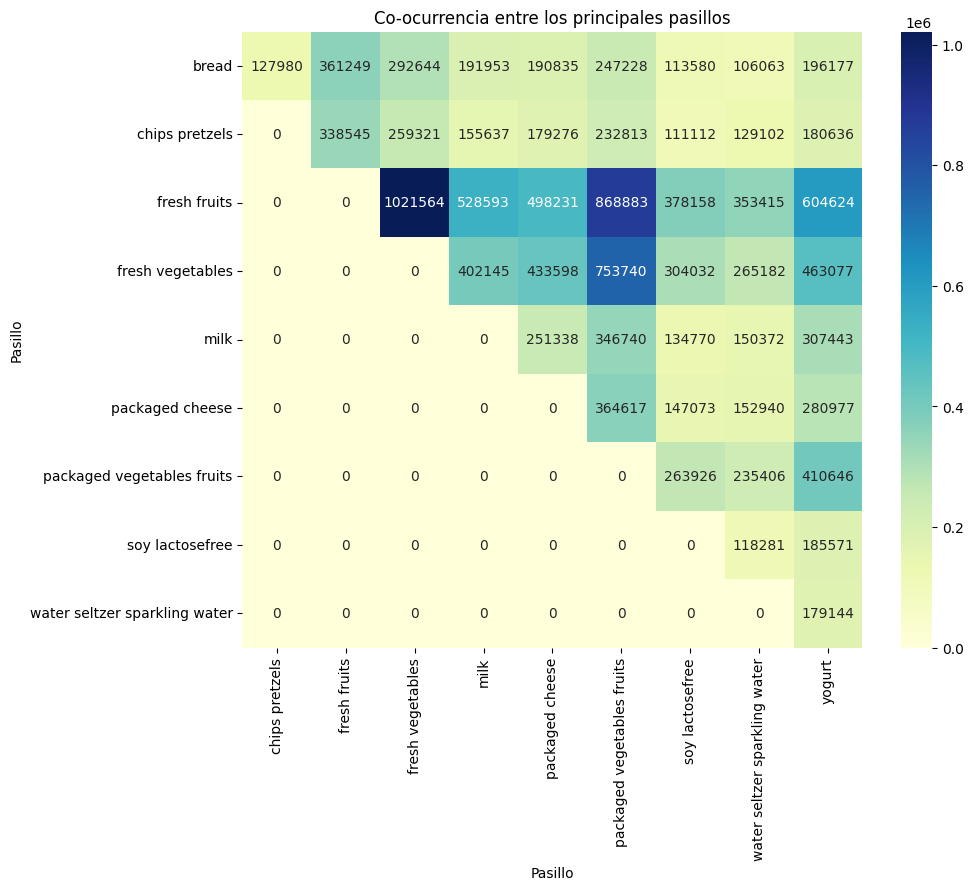

In [48]:
# Obtener los 10 pasillos que más aparecen en los pares de co-ocurrencia

top_aisles = (
    purchases_by_aisle
    .head(10)["aisle"]
    .tolist()
)

# Filtrar únicamente las relaciones entre esos pasillos

heatmap_pairs = pairs_df[
    (pairs_df["aisle_1"].isin(top_aisles)) &
    (pairs_df["aisle_2"].isin(top_aisles))
]

# Construir la matriz de co-ocurrencia

heatmap_data = heatmap_pairs.pivot(
    index="aisle_1",
    columns="aisle_2",
    values="co_occurrence"
)

heatmap_data = heatmap_data.fillna(0)

# Graficar el heatmap

plt.figure(figsize=(10,8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Co-ocurrencia entre los principales pasillos")
plt.xlabel("Pasillo")
plt.ylabel("Pasillo")

plt.show()

### Interpretación

La matriz de co-ocurrencia permite identificar qué categorías aparecen conjuntamente con mayor frecuencia dentro de un mismo pedido.

Se observa una fuerte afinidad entre categorías de productos frescos, lácteos y vegetales, lo que refleja patrones de compra consistentes y hábitos de consumo recurrentes de los usuarios.

Estas relaciones sugieren que un sistema de recomendación puede beneficiarse no solo de recomendar productos similares dentro del mismo pasillo, sino también productos complementarios pertenecientes a categorías con alta afinidad.

Por ejemplo:

- Fresh Fruits ↔ Fresh Vegetables
- Fresh Fruits ↔ Yogurt
- Fresh Fruits ↔ Milk
- Fresh Vegetables ↔ Packaged Vegetables

Estos patrones constituyen oportunidades para estrategias de recomendación basadas en afinidad entre categorías y venta cruzada (*cross-selling*).

## Categorías con mayor afinidad

A partir de la matriz de co-ocurrencia se identifican los pares de categorías que aparecen con mayor frecuencia dentro de un mismo pedido.

Estas relaciones representan oportunidades potenciales para estrategias de recomendación y venta cruzada (*cross-selling*).

In [41]:
pairs_df.sort_values(
    "co_occurrence",
    ascending=False
).head(15)

,aisle_1,aisle_2,co_occurrence
158,fresh fruits,fresh vegetables,1021564
165,fresh fruits,packaged vegetables fruits,868883
19,fresh vegetables,packaged vegetables fruits,753740
422,fresh fruits,yogurt,604624
161,fresh fruits,milk,528593
162,fresh fruits,packaged cheese,498231
35,fresh vegetables,yogurt,463077
174,fresh vegetables,packaged cheese,433598
38,packaged vegetables fruits,yogurt,410646
173,fresh vegetables,milk,402145


### Interpretación

El análisis de co-ocurrencia evidencia que determinadas categorías presentan una elevada afinidad dentro de un mismo pedido.

Estos patrones permiten identificar relaciones de complementariedad entre productos y constituyen una fuente de información relevante para el diseño de sistemas de recomendación.

En función de estos resultados, pueden considerarse diferentes estrategias de modelado:

- Recomendación de productos similares dentro del mismo pasillo.
- Recomendación de productos complementarios pertenecientes a categorías con alta afinidad.
- Modelos basados en reglas de asociación (*Market Basket Analysis*).
- Modelos colaborativos (*Collaborative Filtering*) enriquecidos con información de categorías.

## Diversidad de productos por pasillo

Además de analizar la frecuencia de compra de cada categoría, resulta útil evaluar la diversidad interna de los pasillos.

Para ello se compara la cantidad de productos distintos disponibles en cada pasillo con el volumen total de compras registradas.

Este análisis permite identificar categorías altamente concentradas (pocos productos concentran la mayoría de las compras) y categorías con mayor diversidad, información que puede resultar útil para definir diferentes estrategias de recomendación.

In [49]:
# Diversidad de productos por pasillo

aisle_diversity = (
    prior_full
    .groupby("aisle")
    .agg(
        productos_distintos=("product_id", "nunique"),
        compras_totales=("product_id", "count")
    )
    .reset_index()
)

# Promedio de compras por producto del pasillo

aisle_diversity["compras_promedio_por_producto"] = (
    aisle_diversity["compras_totales"] /
    aisle_diversity["productos_distintos"]
)

aisle_diversity = aisle_diversity.sort_values(
    "compras_promedio_por_producto",
    ascending=False
)

aisle_diversity.head(20)

,aisle,productos_distintos,compras_totales,compras_promedio_por_producto
50,fresh fruits,382,3642188,9534.523560
96,packaged produce,32,276028,8625.875000
53,fresh vegetables,569,3418021,6007.066784
51,fresh herbs,86,377741,4392.337209
83,milk,243,891015,3666.728395
41,eggs,125,452134,3617.072000
98,packaged vegetables fruits,615,1765313,2870.427642
131,water seltzer sparkling water,344,841533,2446.316860
119,soy lactosefree,293,638253,2178.337884
33,cream,161,318002,1975.167702


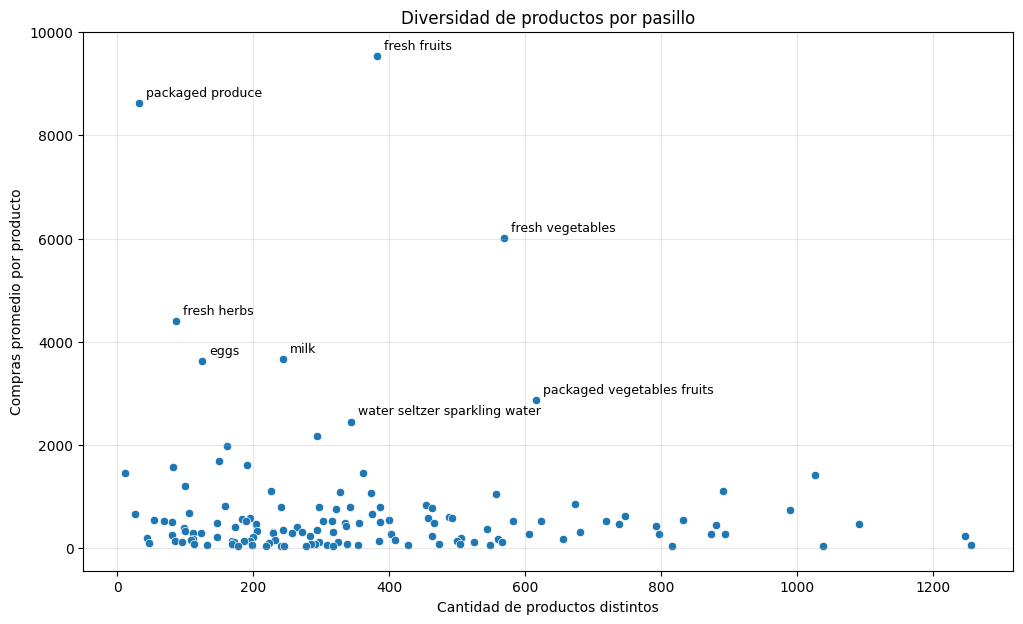

In [52]:
plt.figure(figsize=(12,7))

sns.scatterplot(
    data=aisle_diversity,
    x="productos_distintos",
    y="compras_promedio_por_producto"
)

plt.xlabel("Cantidad de productos distintos")
plt.ylabel("Compras promedio por producto")
plt.title("Diversidad de productos por pasillo")

plt.grid(alpha=0.3)

# Etiquetar los 8 pasillos con mayor promedio

top_diversity = aisle_diversity.head(8)

for _, row in top_diversity.iterrows():
    plt.annotate(
        row["aisle"],
        (
            row["productos_distintos"],
            row["compras_promedio_por_producto"]
        ),
        xytext=(5,5),
        textcoords="offset points",
        fontsize=9
    )

plt.show()

### Interpretación

El análisis muestra que la relación entre la cantidad de productos disponibles en un pasillo y su volumen de compras no es uniforme.

Algunas categorías, como **Fresh Fruits**, **Packaged Produce** y **Fresh Vegetables**, concentran un elevado número de compras promedio por producto, aun contando con cientos de artículos distintos. Esto indica que la demanda se encuentra fuertemente concentrada en un subconjunto reducido de productos muy populares.

En contraste, otros pasillos presentan una gran cantidad de productos distintos, pero un promedio de compras considerablemente menor, reflejando una distribución más dispersa de las interacciones entre los distintos artículos.

Estos resultados sugieren que no todas las categorías deberían abordarse de la misma manera en el sistema de recomendación. Mientras que en categorías altamente concentradas podría resultar conveniente recomendar productos similares dentro del mismo pasillo, en categorías con mayor diversidad podría ser más útil complementar las recomendaciones utilizando información de afinidad entre pasillos o patrones de compra conjunta.

Este comportamiento refuerza la importancia de adaptar las estrategias de recomendación al contexto de cada categoría, en lugar de aplicar un único criterio para todo el catálogo.

# Probabilidad de compra entre categorías

## Objetivo

La co-ocurrencia permite identificar qué categorías aparecen juntas dentro de un mismo pedido, pero no indica la probabilidad de que una categoría sea comprada cuando otra ya está presente.

En esta sección se calcula la probabilidad condicional entre pasillos, con el objetivo de identificar relaciones de compra que puedan utilizarse como base para recomendaciones de productos complementarios (*cross-selling*).

Este análisis busca responder preguntas como:

- Si un usuario compra frutas frescas, ¿qué otras categorías suele incorporar al pedido?
- ¿Existen relaciones suficientemente fuertes como para justificar recomendaciones entre categorías?

In [53]:
#Paso 1 - Pedidos por pasillo
# Obtener los pasillos presentes en cada pedido

order_aisles = (
    prior_full
    .groupby("order_id")["aisle"]
    .apply(lambda x: sorted(set(x)))
)

order_aisles.head()

order_id
2    [baking ingredients, doughs gelatins bake mixe...
3    [bread, fresh vegetables, packaged vegetables ...
4    [breakfast bakery, breakfast bars pastries, ch...
5    [body lotions soap, candy chocolate, cookies c...
6      [air fresheners candles, laundry, refrigerated]
Name: aisle, dtype: object

In [54]:
#Paso 2 - Cantidad de pedidos por pasillo

from collections import Counter

aisle_counter = Counter()

for aisles in order_aisles:
    aisle_counter.update(aisles)

aisle_orders = pd.DataFrame(
    aisle_counter.items(),
    columns=["aisle", "orders"]
)

aisle_orders.head()

,aisle,orders
0,baking ingredients,246753
1,doughs gelatins bake mixes,89464
2,eggs,440410
3,fresh vegetables,1427631
4,oils vinegars,217643


In [55]:
#Paso 3 - Probabilidad condicional
# Unir las co-ocurrencias con la cantidad de pedidos del pasillo origen

prob_pairs = (
    pairs_df
    .merge(
        aisle_orders,
        left_on="aisle_1",
        right_on="aisle",
        how="left"
    )
)

prob_pairs["conditional_probability"] = (
    prob_pairs["co_occurrence"] /
    prob_pairs["orders"]
)

prob_pairs = (
    prob_pairs
    .sort_values(
        "conditional_probability",
        ascending=False
    )
)

prob_pairs.head(20)

,aisle_1,aisle_2,co_occurrence,aisle,orders,conditional_probability
312,fresh herbs,fresh vegetables,253545,fresh herbs,300364,0.844126
4961,bulk grains rice dried goods,fresh fruits,12845,bulk grains rice dried goods,16822,0.763583
715,canned jarred vegetables,fresh vegetables,180120,canned jarred vegetables,236569,0.761385
1232,bulk grains rice dried goods,fresh vegetables,12451,bulk grains rice dried goods,16822,0.740162
297,baby food formula,fresh fruits,109799,baby food formula,148388,0.739945
304,canned meals beans,fresh vegetables,160399,canned meals beans,223882,0.716444
1722,canned fruit applesauce,fresh fruits,55472,canned fruit applesauce,77802,0.712989
475,bulk dried fruits vegetables,fresh fruits,12250,bulk dried fruits vegetables,17242,0.710474
302,canned meals beans,fresh fruits,158573,canned meals beans,223882,0.708288
744,fresh dips tapenades,fresh fruits,223047,fresh dips tapenades,314910,0.708288


In [56]:
#Paso 4 - Top relaciones

top_prob = (
    prob_pairs[
        [
            "aisle_1",
            "aisle_2",
            "conditional_probability",
            "co_occurrence"
        ]
    ]
    .head(20)
)

top_prob

,aisle_1,aisle_2,conditional_probability,co_occurrence
312,fresh herbs,fresh vegetables,0.844126,253545
4961,bulk grains rice dried goods,fresh fruits,0.763583,12845
715,canned jarred vegetables,fresh vegetables,0.761385,180120
1232,bulk grains rice dried goods,fresh vegetables,0.740162,12451
297,baby food formula,fresh fruits,0.739945,109799
304,canned meals beans,fresh vegetables,0.716444,160399
1722,canned fruit applesauce,fresh fruits,0.712989,55472
475,bulk dried fruits vegetables,fresh fruits,0.710474,12250
302,canned meals beans,fresh fruits,0.708288,158573
744,fresh dips tapenades,fresh fruits,0.708288,223047


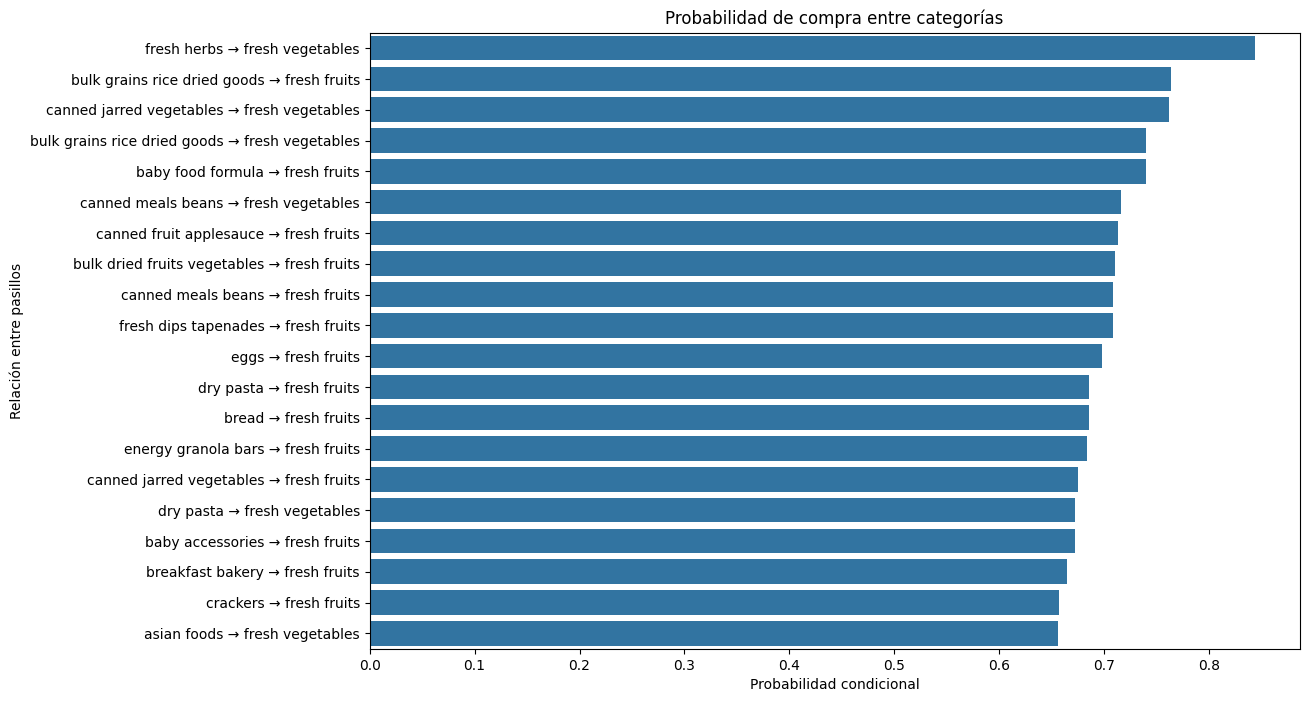

In [57]:
# Paso 5 - Gráfico
plt.figure(figsize=(12,8))

sns.barplot(
    data=top_prob,
    x="conditional_probability",
    y=top_prob["aisle_1"] + " → " + top_prob["aisle_2"]
)

plt.xlabel("Probabilidad condicional")
plt.ylabel("Relación entre pasillos")
plt.title("Probabilidad de compra entre categorías")

plt.show()

### Interpretación

El análisis de probabilidad condicional permite cuantificar la fuerza de asociación entre categorías, respondiendo a la pregunta: **¿qué tan probable es encontrar un determinado pasillo cuando otro ya está presente en el pedido?**

Los resultados muestran asociaciones muy marcadas entre determinadas categorías. Entre las relaciones con mayor probabilidad se destacan:

- **Fresh Herbs → Fresh Vegetables:** **84,4%**
- **Bulk Grains Rice Dried Goods → Fresh Fruits:** **76,4%**
- **Canned Jarred Vegetables → Fresh Vegetables:** **76,1%**
- **Bulk Grains Rice Dried Goods → Fresh Vegetables:** **74,0%**
- **Baby Food Formula → Fresh Fruits:** **74,0%**

Asimismo, categorías de alta frecuencia como **Bread**, **Eggs**, **Dry Pasta** y **Crackers** presentan probabilidades cercanas al **70%** de aparecer en pedidos que también contienen **Fresh Fruits**, evidenciando que esta categoría funciona como un eje central dentro de numerosos patrones de compra.

Estos resultados indican que la relación entre categorías no depende únicamente de la cantidad de compras compartidas, sino también de la fuerza de asociación entre ellas. En consecuencia, estas probabilidades constituyen una fuente de información valiosa para complementar los modelos de recomendación tradicionales, permitiendo sugerir no solo productos similares, sino también productos complementarios con alta probabilidad de ser adquiridos conjuntamente.

# Análisis de la fuerza de asociación entre categorías (Lift)

## Objetivo

Hasta el momento se analizaron la co-ocurrencia y la probabilidad condicional entre pasillos. Sin embargo, estas métricas pueden verse influenciadas por categorías que aparecen con mucha frecuencia en los pedidos, como **Fresh Fruits** o **Fresh Vegetables**.

Para evaluar si una asociación entre dos categorías es realmente significativa, se calcula la métrica **Lift**, ampliamente utilizada en técnicas de **Market Basket Analysis**.

El Lift compara la probabilidad observada de que dos categorías aparezcan juntas con la probabilidad esperada si ambas fueran independientes.

Se define como:

\[
Lift(A,B)=\frac{P(B|A)}{P(B)}
\]

Su interpretación es la siguiente:

- **Lift = 1:** ambas categorías son independientes.
- **Lift > 1:** la presencia de una categoría aumenta la probabilidad de encontrar la otra.
- **Lift < 1:** ambas categorías aparecen juntas menos veces de lo esperado.

Esta métrica permite identificar asociaciones realmente relevantes para el sistema de recomendación, evitando que categorías muy populares dominen el análisis únicamente por su alta frecuencia de compra.

In [58]:
# Cantidad total de pedidos

total_orders = prior_full["order_id"].nunique()

print(total_orders)

3214874


In [59]:
# Probabilidad de aparición de cada pasillo

aisle_orders["probability"] = (
    aisle_orders["orders"] /
    total_orders
)

aisle_orders.head()

,aisle,orders,probability
0,baking ingredients,246753,0.076754
1,doughs gelatins bake mixes,89464,0.027828
2,eggs,440410,0.136991
3,fresh vegetables,1427631,0.444071
4,oils vinegars,217643,0.067699


In [60]:
lift_df = (
    prob_pairs
    .merge(
        aisle_orders[
            ["aisle","probability"]
        ],
        left_on="aisle_2",
        right_on="aisle",
        how="left"
    )
)

In [61]:
lift_df["lift"] = (
    lift_df["conditional_probability"] /
    lift_df["probability"]
)

In [62]:
lift_df = (
    lift_df
    .sort_values(
        "lift",
        ascending=False
    )
)

lift_df[
    [
        "aisle_1",
        "aisle_2",
        "conditional_probability",
        "lift"
    ]
].head(20)

,aisle_1,aisle_2,conditional_probability,lift
351,red wines,white wines,0.305777,38.902823
663,specialty wines champagnes,white wines,0.214062,27.234217
2762,red wines,specialty wines champagnes,0.081601,26.538956
928,beers coolers,red wines,0.178723,22.704929
1194,specialty wines champagnes,spirits,0.149722,21.002562
1154,beers coolers,white wines,0.153580,19.539349
3637,facial care,shave needs,0.056235,18.978549
1201,spirits,white wines,0.149140,18.974539
1464,beers coolers,spirits,0.131765,18.483590
3660,beers coolers,specialty wines champagnes,0.055866,18.169013


### Interpretación

A diferencia de la probabilidad condicional, la métrica **Lift** permite identificar asociaciones que son significativamente más frecuentes de lo que cabría esperar por azar, corrigiendo el efecto de las categorías con alta frecuencia de compra.

Los resultados muestran asociaciones muy fuertes entre categorías relacionadas. Entre las reglas con mayor Lift se encuentran:

- **Red Wines → White Wines:** Lift = **38.90**
- **Specialty Wines & Champagnes → White Wines:** Lift = **27.23**
- **Red Wines → Specialty Wines & Champagnes:** Lift = **26.54**
- **Beers Coolers → Red Wines:** Lift = **22.70**
- **Specialty Wines & Champagnes → Spirits:** Lift = **21.00**

También se observan asociaciones relevantes en otras familias de productos, como:

- **Facial Care → Shave Needs:** Lift = **18.98**
- **Beauty → Eye Care:** Lift = **16.74**
- **Baby Accessories → Diapers & Wipes:** Lift = **13.64**

Estos resultados evidencian que determinadas categorías presentan relaciones de compra considerablemente más fuertes que las esperadas por su frecuencia individual.

Desde la perspectiva del sistema de recomendación, estas asociaciones representan oportunidades para generar recomendaciones de productos complementarios y estrategias de venta cruzada (*cross-selling*), enriqueciendo los modelos colaborativos con información proveniente de los patrones reales de compra observados en el dataset.

### Interpretación

A diferencia de la probabilidad condicional, la métrica **Lift** permite identificar asociaciones que son significativamente más frecuentes de lo que cabría esperar por azar, corrigiendo el efecto de las categorías con alta frecuencia de compra.

Los resultados muestran asociaciones muy fuertes entre categorías relacionadas. Entre las reglas con mayor Lift se encuentran:

- **Red Wines → White Wines:** Lift = **38.90**
- **Specialty Wines & Champagnes → White Wines:** Lift = **27.23**
- **Red Wines → Specialty Wines & Champagnes:** Lift = **26.54**
- **Beers Coolers → Red Wines:** Lift = **22.70**
- **Specialty Wines & Champagnes → Spirits:** Lift = **21.00**

También se observan asociaciones relevantes en otras familias de productos, como:

- **Facial Care → Shave Needs:** Lift = **18.98**
- **Beauty → Eye Care:** Lift = **16.74**
- **Baby Accessories → Diapers & Wipes:** Lift = **13.64**

Estos resultados evidencian que determinadas categorías presentan relaciones de compra considerablemente más fuertes que las esperadas por su frecuencia individual.

Desde la perspectiva del sistema de recomendación, estas asociaciones representan oportunidades para generar recomendaciones de productos complementarios y estrategias de venta cruzada (*cross-selling*), enriqueciendo los modelos colaborativos con información proveniente de los patrones reales de compra observados en el dataset.

In [71]:
import networkx as nx
print(nx.__version__)

3.6.1


In [72]:
# Seleccionar las reglas con mayor Lift
# Se filtran reglas con suficiente co-ocurrencia para evitar relaciones muy raras

top_lift_edges = (
    lift_df[
        lift_df["co_occurrence"] >= 5000
    ]
    .sort_values("lift", ascending=False)
    .head(20)
)

top_lift_edges[
    ["aisle_1", "aisle_2", "conditional_probability", "lift", "co_occurrence"]
]

,aisle_1,aisle_2,conditional_probability,lift,co_occurrence
351,red wines,white wines,0.305777,38.902823,7738
928,beers coolers,red wines,0.178723,22.704929,5317
1114,cleaning products,laundry,0.157411,6.322606,13928
726,frozen vegan vegetarian,tofu meat alternatives,0.205803,6.238860,16122
1105,body lotions soap,cleaning products,0.158298,5.751532,5624
1369,dish detergents,laundry,0.137437,5.520356,12096
1312,cleaning products,dish detergents,0.141396,5.164926,12511
382,body lotions soap,paper goods,0.295542,4.709693,10500
4189,paper goods,trash bags liners,0.044374,4.655919,8952
6542,ice cream ice,ice cream toppings,0.014330,4.544504,5055


In [73]:
# Crear grafo de afinidad

G = nx.Graph()

for _, row in top_lift_edges.iterrows():
    G.add_edge(
        row["aisle_1"],
        row["aisle_2"],
        weight=row["lift"]
    )

In [80]:
# Conservar únicamente asociaciones fuertes

top_lift_edges = (
    lift_df[
        (lift_df["lift"] >= 6) &
        (lift_df["co_occurrence"] >= 8000)
    ]
    .sort_values("lift", ascending=False)
)

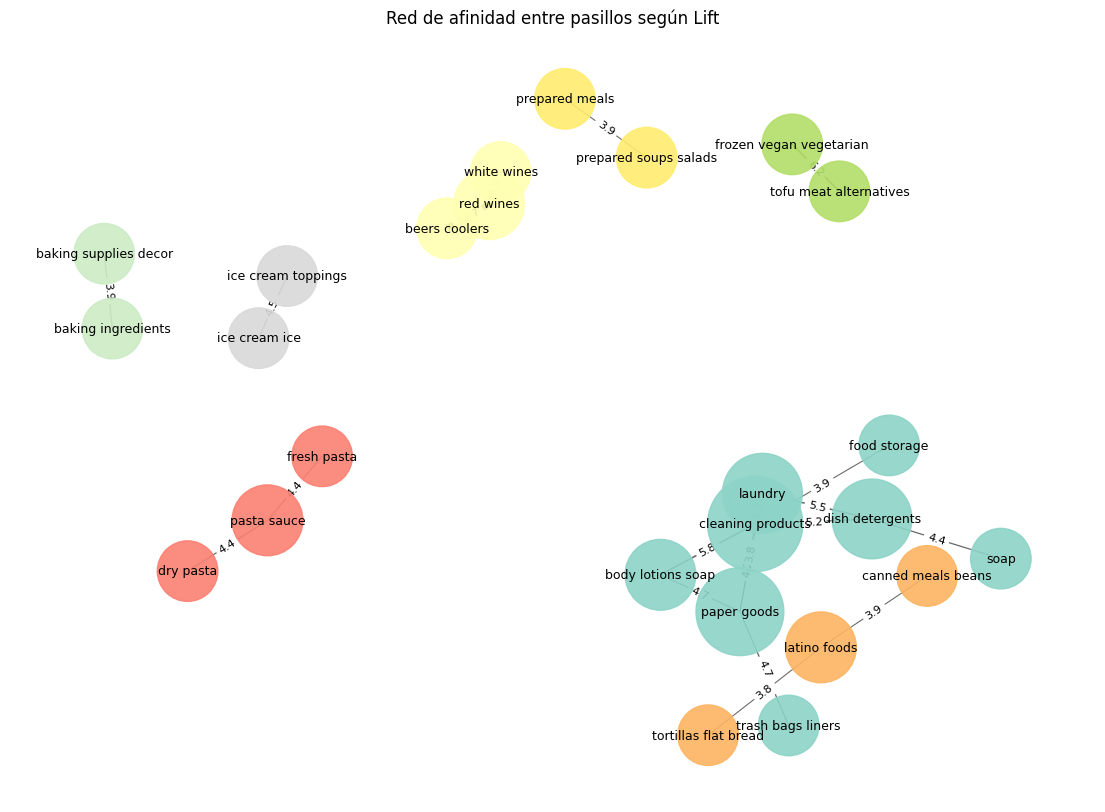

In [ ]:
# Visualizar red de afinidad con comunidades

from networkx.algorithms.community import greedy_modularity_communities

# Detectar comunidades dentro del grafo
communities = list(greedy_modularity_communities(G))

# Asignar un número de comunidad a cada nodo
node_community = {}

for i, community in enumerate(communities):
    for node in community:
        node_community[node] = i

# Crear lista de colores según comunidad
node_colors = [
    node_community[node]
    for node in G.nodes()
]

plt.figure(figsize=(14, 10))

# Posición de los nodos
pos = nx.spring_layout(
    G,
    seed=42,
    k=0.8
)

# Pesos de las conexiones según Lift
edge_weights = [
    G[u][v]["weight"] for u, v in G.edges()
]

# Tamaño de nodos según cantidad de conexiones
node_sizes = [
    1200 + 700 * G.degree(node)
    for node in G.nodes()
]

# Dibujar nodos con color por comunidad
nx.draw_networkx_nodes(
    G,
    pos,
    node_size=node_sizes,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    alpha=0.9
)

# Dibujar conexiones
nx.draw_networkx_edges(
    G,
    pos,
    width=[w / 5 for w in edge_weights],
    alpha=0.6
)

# Dibujar nombres de pasillos
nx.draw_networkx_labels(
    G,
    pos,
    font_size=9
)

# Etiquetas de Lift en cada conexión
edge_labels = {
    (u, v): f'{G[u][v]["weight"]:.1f}'
    for u, v in G.edges()
}

nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels=edge_labels,
    font_size=8
)

plt.title("Red de afinidad entre pasillos según Lift")
plt.axis("off")
plt.show()

### Interpretación

La red de afinidad construida a partir de las reglas con mayor **Lift** evidencia la existencia de comunidades naturales de categorías que presentan patrones de compra significativamente superiores a los esperados por azar.

Entre las asociaciones más fuertes identificadas se destacan:

- **Red Wines ↔ White Wines** (Lift = **38.90**)
- **Beers Coolers ↔ Red Wines** (Lift = **22.70**)
- **Cleaning Products ↔ Laundry** (Lift = **6.32**)
- **Frozen Vegan Vegetarian ↔ Tofu Meat Alternatives** (Lift = **6.24**)
- **Body Lotions Soap ↔ Cleaning Products** (Lift = **5.75**)

Además de las relaciones individuales, la detección automática de comunidades permite identificar agrupamientos temáticos claramente diferenciados, correspondientes a bebidas alcohólicas, productos de limpieza del hogar, pastas, repostería, productos veganos, comidas preparadas y helados.

Estos resultados muestran que las relaciones entre categorías no dependen únicamente de su popularidad, sino que reflejan patrones reales de compra de los usuarios. En consecuencia, las recomendaciones no deberían limitarse únicamente a productos similares, sino también incorporar categorías complementarias que forman parte de un mismo contexto de consumo.

Desde la perspectiva del sistema de recomendación, este análisis aporta evidencia para implementar estrategias de **cross-selling**, reglas de asociación (*Market Basket Analysis*) y modelos híbridos que combinen la similitud entre usuarios o productos con la afinidad existente entre categorías.

# Implicancias para el modelado

Los hallazgos obtenidos durante el análisis exploratorio permiten orientar las decisiones de preprocesamiento y modelado del sistema de recomendación.

En particular, se identifican las siguientes implicancias:

- Reducir el ruido eliminando productos con muy baja frecuencia de compra, minimizando el impacto del efecto **Long Tail**.
- Evitar la aplicación de umbrales globales, considerando que cada pasillo presenta una dinámica de consumo diferente.
- Definir criterios de filtrado relativos por categoría utilizando métricas robustas, como la mediana o los percentiles.
- Preservar la diversidad de productos dentro de cada pasillo, evitando eliminar artículos representativos de categorías naturalmente menos frecuentes.
- Incorporar información contextual, como **pasillo (aisle)**, **departamento (department)** y **frecuencia de recompra (reordered)**, como variables adicionales para enriquecer los modelos.
- Aprovechar la afinidad entre categorías identificada mediante **co-ocurrencia**, **probabilidad condicional** y **Lift**, permitiendo generar recomendaciones de productos complementarios además de productos similares.
- Utilizar las reglas de asociación detectadas como base para estrategias de **Market Basket Analysis**, **cross-selling** y modelos híbridos que combinen similitud entre usuarios o productos con relaciones entre categorías.

De esta manera, las decisiones de preprocesamiento y selección de modelos quedan respaldadas por evidencia obtenida directamente del comportamiento observado en el dataset, en lugar de responder únicamente a criterios arbitrarios.

# Conclusiones del Análisis Exploratorio

El análisis exploratorio permitió caracterizar el comportamiento general del dataset y comprender los principales patrones de compra presentes en Instacart.

En primer lugar, se verificó la existencia de un marcado efecto **Long Tail**, donde una pequeña proporción de productos concentra la mayor parte de las compras, mientras que una gran cantidad de artículos presenta una frecuencia muy baja de interacción. Asimismo, se observó que este comportamiento también se replica dentro de los distintos pasillos, evidenciando que cada categoría posee una dinámica de consumo propia.

El estudio de la distribución de compras por categoría mostró que la media suele encontrarse considerablemente por encima de la mediana, reflejando distribuciones altamente asimétricas y reforzando la necesidad de utilizar métricas robustas para definir estrategias de filtrado y reducción de ruido.

Posteriormente, el análisis de co-ocurrencia, probabilidad condicional y **Lift** permitió identificar asociaciones relevantes entre categorías, revelando comunidades de productos que los usuarios adquieren conjuntamente con una frecuencia significativamente superior a la esperada por azar. Estos resultados evidencian que los patrones de compra no dependen únicamente de la popularidad de los productos, sino también de relaciones de complementariedad entre distintas categorías.

En conjunto, estos hallazgos justifican el desarrollo de sistemas de recomendación que combinen múltiples enfoques. Además de los modelos colaborativos tradicionales, el análisis sugiere incorporar información proveniente de reglas de asociación y afinidad entre categorías, permitiendo generar recomendaciones tanto de productos similares como de productos complementarios.

Finalmente, el conocimiento obtenido durante esta etapa constituye la base para las siguientes fases del proyecto, orientando las decisiones de preprocesamiento, ingeniería de características y selección de modelos con evidencia extraída directamente del comportamiento real de los usuarios y sus patrones de compra.